# Define Stats Recipe

In [1]:
from nvflare.app_opt.pt.recipes.fedstats import FedStatsRecipe
from nvflare.recipe.prod_env import ProdEnv

recipe = FedStatsRecipe(
    name="fedstats",
    sites=["site5"],
    data_path="/workspace/dataset/mlg-ulb/creditcardfraud/versions/3/creditcard.csv",  # assumes each client uses the same path
    stats_output_path="statistics/credit_card_stats.json"
)

recipe.export("transfer")

# Run in Production Environment

In [2]:
env = ProdEnv(startup_kit_dir=".")
recipe.execute(env=env)


Connecting to FLARE ...
deploy temp_dir: /tmp/tmpr9ce8ryp
deploy job.name: fed_job
submitted job: b867cbb3-5144-4208-a03b-5904c728da6b


'b867cbb3-5144-4208-a03b-5904c728da6b'

In [3]:
job_id = "b867cbb3-5144-4208-a03b-5904c728da6b"

import os
from nvflare.fuel.flare_api.flare_api import new_secure_session
 
username = "admin@nvidia.com"
sess = new_secure_session(
    username=username,
    startup_kit_location=".",
    timeout=30
)
print(sess.get_system_info())

Connecting to FLARE ...
SystemInfo
server_info:
status: stopped, start_time: Fri Aug 22 19:27:22 2025
client_info:
site5(last_connect_time: Thu Aug 28 15:48:07 2025)
job_info:



In [10]:
from nvflare.fuel.flare_api.flare_api import Session

def sample_cb(
        session: Session, job_id: str, job_meta, *cb_args, **cb_kwargs
    ) -> bool:
    """
    Custom callback function for job monitoring.
    
    Args:
        session: The FLARE session
        job_id: The ID of the job being monitored
        job_meta: Metadata about the job's current state
        cb_args: Additional positional arguments
        cb_kwargs: Additional keyword arguments
        
    Returns:
        bool: True to continue monitoring, False to stop
    """
    if job_meta["status"] == "RUNNING":
        if cb_kwargs["cb_run_counter"]["count"] < 1:
            print(job_meta)
            print(cb_kwargs["cb_run_counter"])
        else:
            print(".", end="")
    else:
        print("\n" + str(job_meta))
    
    cb_kwargs["cb_run_counter"]["count"] += 1
    return True

# Monitor the job with our custom callback
print(f"Monitoring job {job_id}...")
#result = sess.monitor_job(job_id, cb=sample_cb, cb_run_counter={"count":0})
result = sess.monitor_job(job_id)
print(f"\nMonitoring completed with result: {result}")

Monitoring job b867cbb3-5144-4208-a03b-5904c728da6b...

Monitoring completed with result: MonitorReturnCode.JOB_FINISHED


# Download results

In [5]:
result_path = sess.download_job_result(job_id)
stats_file = result_path + '/workspace/statistics/credit_card_stats.json'
print(job_id, stats_file)

b867cbb3-5144-4208-a03b-5904c728da6b ./transfer/b867cbb3-5144-4208-a03b-5904c728da6b/workspace/statistics/credit_card_stats.json


# Show stats

In [6]:
!head -c 200 {stats_file}

{"Time": {"count": {"site5": {"train": 227846, "test": 56961}, "Global": {"train": 227846, "test": 56961}}, "mean": {"site5": {"train": 94840.9019, "test": 94705.6892}, "Global": {"train": 94840.9019,

In [7]:
import json
import pandas as pd

from nvflare.app_opt.statistics.visualization.statistics_visualization import Visualization

with open(stats_file, 'r') as f:
    data = json.load(f)

## Overall stats

In [8]:
vis = Visualization()
vis.show_stats(data = data)


Time



,count,mean,sum,stddev,histogram
site5-train,227846,94840.9019,2.160912e+10,47482.2112,"[[0.0, 3223.9725, 2981], [3223.9725, 6447.9449..."
site5-test,56961,94705.6892,5.394531e+09,47512.1410,"[[0.0, 3223.9725, 755], [3223.9725, 6447.9449,..."
Global-train,227846,94840.9019,2.160912e+10,47482.2112,"[[0.0, 3223.9725, 2981], [3223.9725, 6447.9449..."
Global-test,56961,94705.6892,5.394531e+09,47512.1410,"[[0.0, 3223.9725, 755], [3223.9725, 6447.9449,..."



V1



,count,mean,sum,stddev,histogram
site5-train,227846,0.0029,671.998,1.9520,"[[-65.6012, -64.5287, 0], [-64.5287, -63.4562,..."
site5-test,56961,-0.0118,-671.998,1.9853,"[[-65.6012, -64.5287, 0], [-64.5287, -63.4562,..."
Global-train,227846,0.0029,671.998,1.9520,"[[-65.6012, -64.5287, 0], [-64.5287, -63.4562,..."
Global-test,56961,-0.0118,-671.998,1.9853,"[[-65.6012, -64.5287, 0], [-64.5287, -63.4562,..."



V2



...

,count,mean,sum,stddev,histogram
site5-train,227846,0.0003,65.0938,0.3281,"[[-17.4857, -16.6143, 0], [-16.6143, -15.7428,..."
site5-test,56961,-0.0011,-65.0938,0.3380,"[[-17.4857, -16.6143, 0], [-16.6143, -15.7428,..."
Global-train,227846,0.0003,65.0938,0.3280,"[[-17.4857, -16.6143, 0], [-16.6143, -15.7428,..."
Global-test,56961,-0.0011,-65.0938,0.3381,"[[-17.4857, -16.6143, 0], [-16.6143, -15.7428,..."



Amount



,count,mean,sum,stddev,histogram
site5-train,227846,88.0657,20065414.31,244.3511,"[[0.0, 509.4669, 220706], [509.4669, 1018.9338..."
site5-test,56961,89.4854,5097175.70,271.9748,"[[0.0, 509.4669, 55174], [509.4669, 1018.9338,..."
Global-train,227846,88.0657,20065414.31,244.3511,"[[0.0, 509.4669, 220706], [509.4669, 1018.9338..."
Global-test,56961,89.4854,5097175.70,271.9748,"[[0.0, 509.4669, 55174], [509.4669, 1018.9338,..."



Class



,count,mean,sum,stddev,histogram
site5-train,227846,0.0017,394,0.0415,"[[0.0, 0.0189, 227452], [0.0189, 0.0378, 0], [..."
site5-test,56961,0.0017,98,0.0414,"[[0.0, 0.0189, 56863], [0.0189, 0.0378, 0], [0..."
Global-train,227846,0.0017,394,0.0412,"[[0.0, 0.0189, 227452], [0.0189, 0.0378, 0], [..."
Global-test,56961,0.0017,98,0.0412,"[[0.0, 0.0189, 56863], [0.0189, 0.0378, 0], [0..."


## Histogram Visualization

(see [here](https://github.com/NVIDIA/NVFlare/blob/main/examples/advanced/federated-statistics/df_stats/demo/visualization.ipynb) for more display options)

/scratch/hroth/Code/JPM/.venv_jpm/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


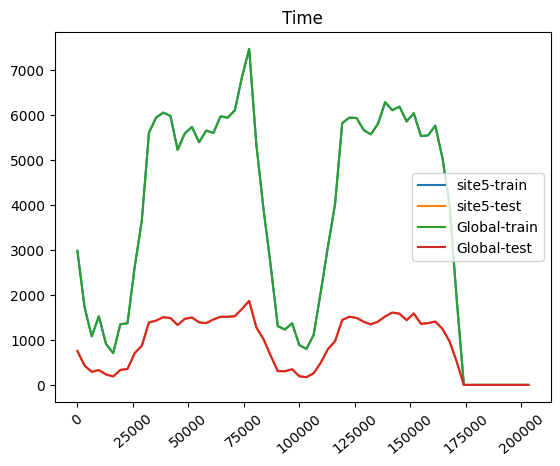

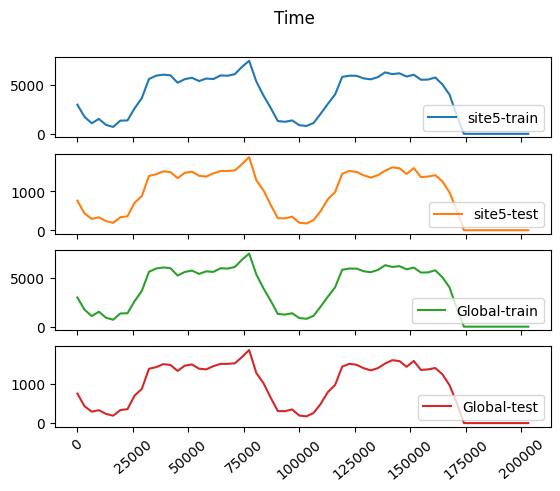

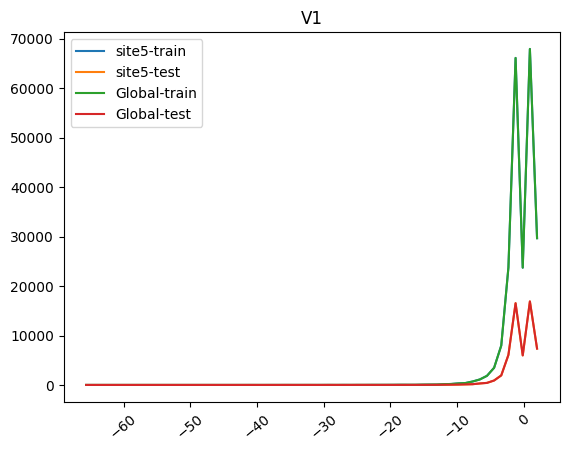

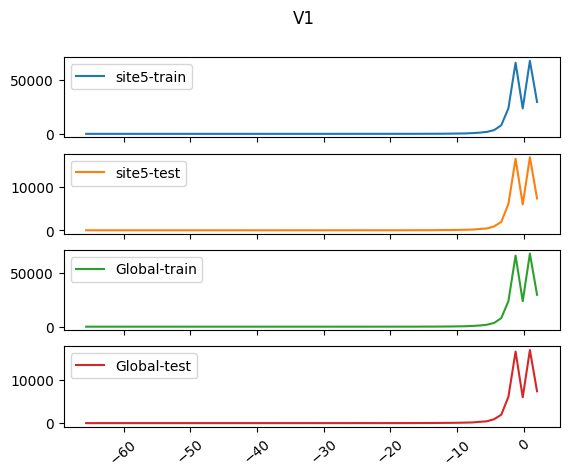

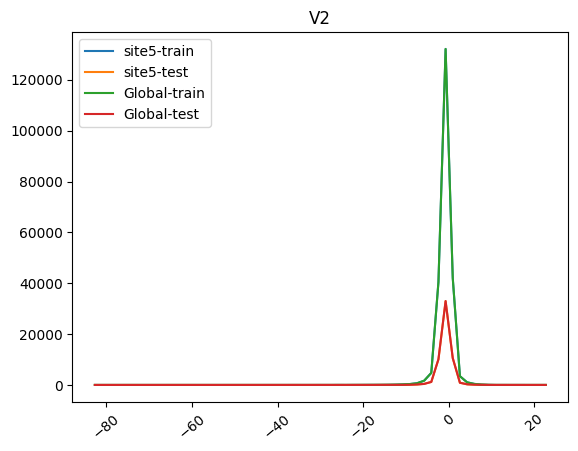

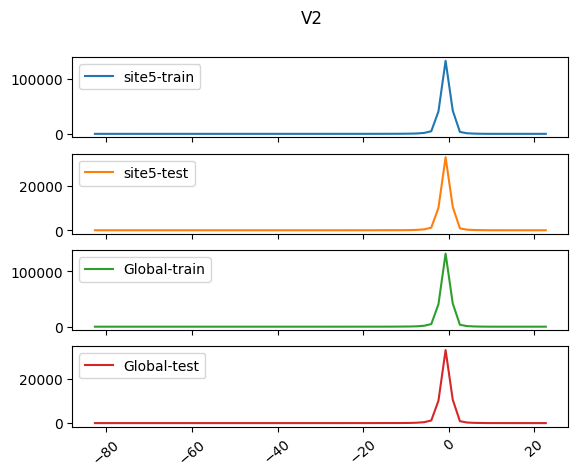

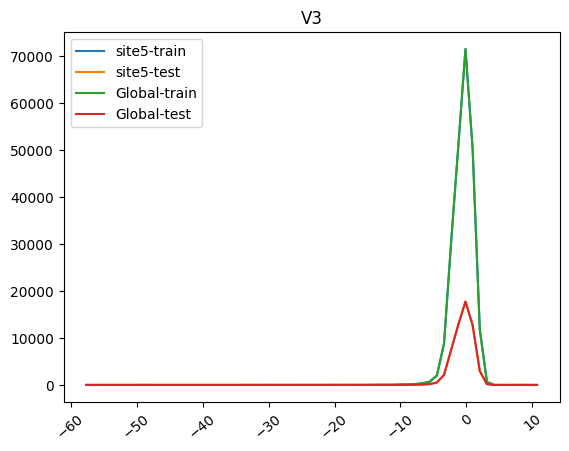

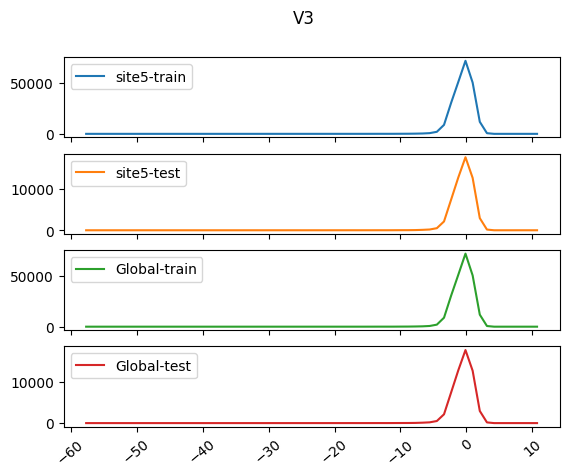

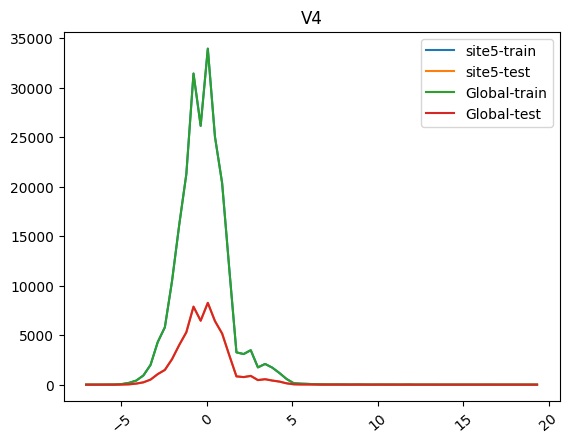

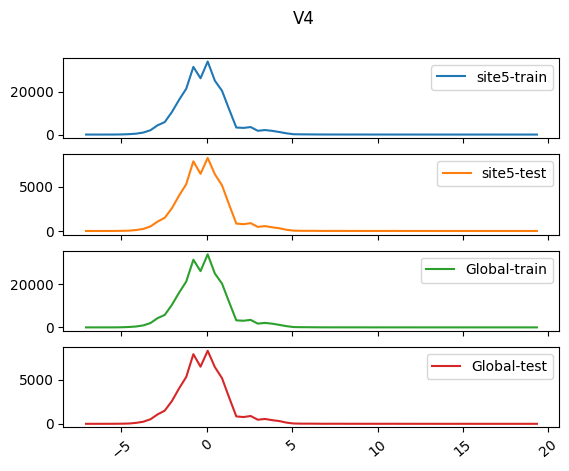

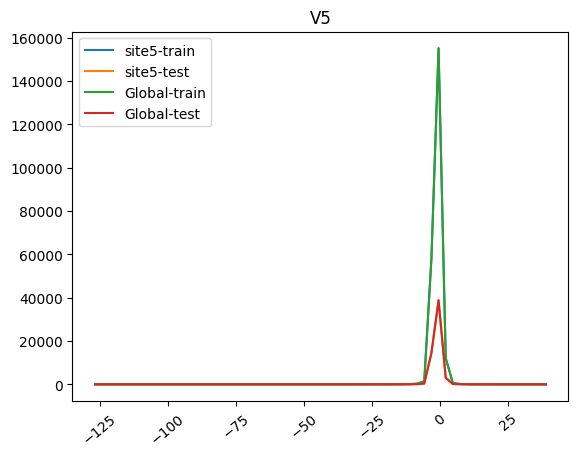

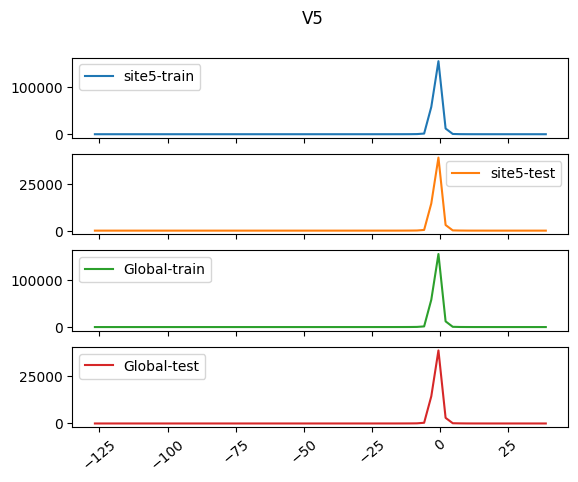

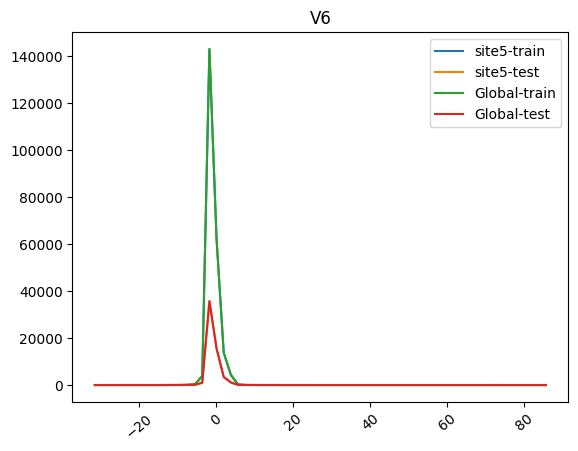

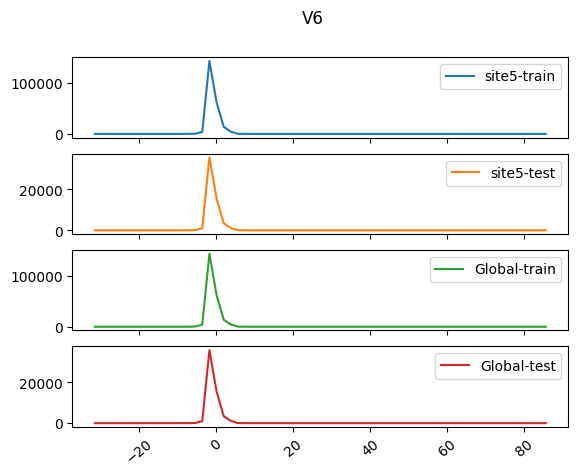

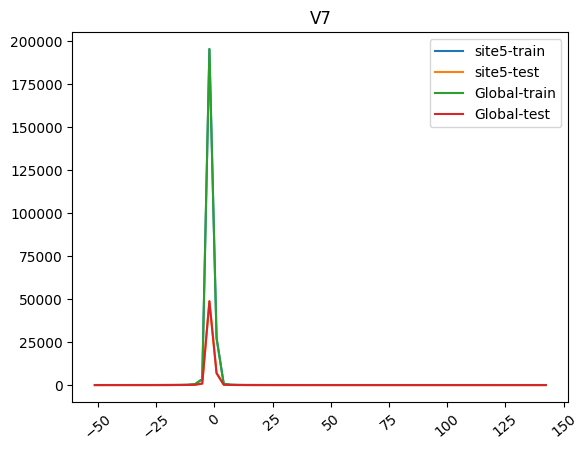

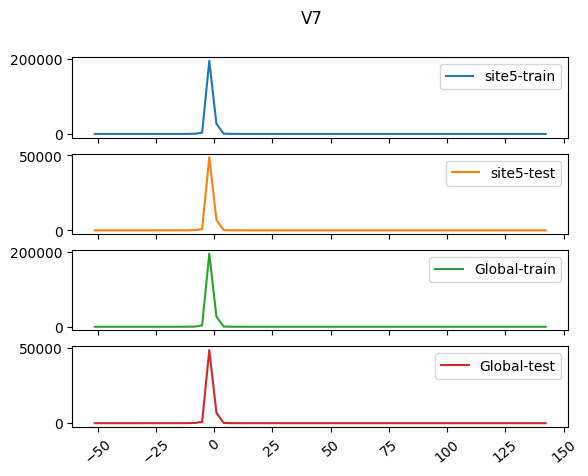

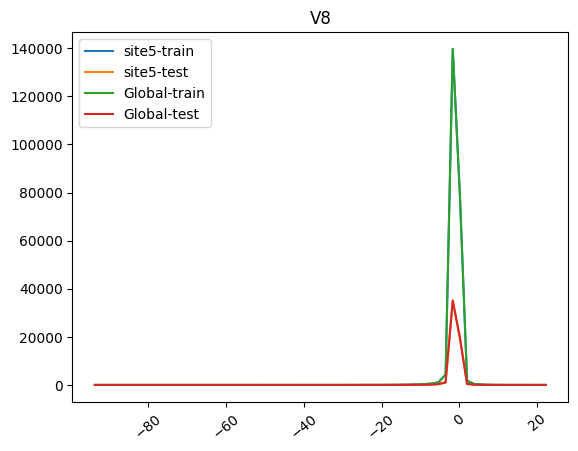

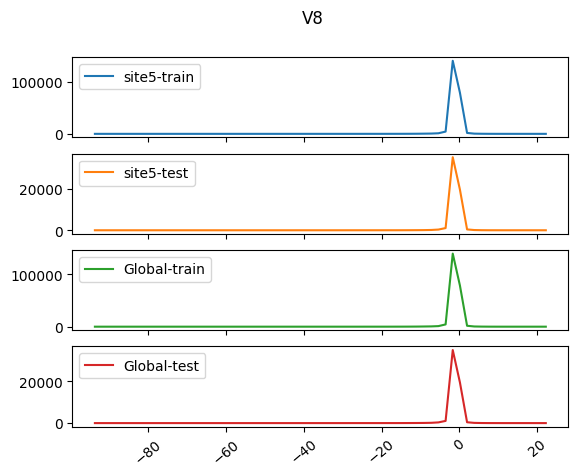

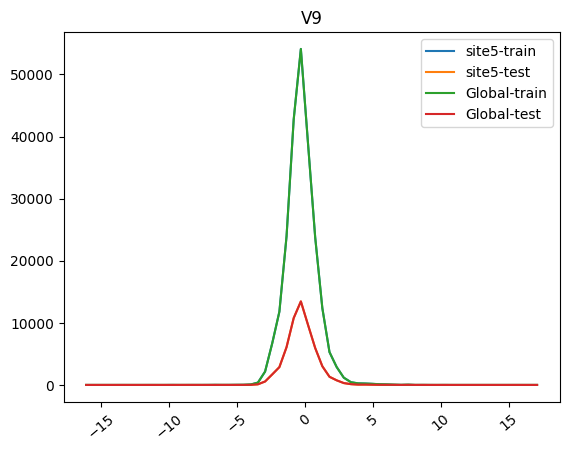

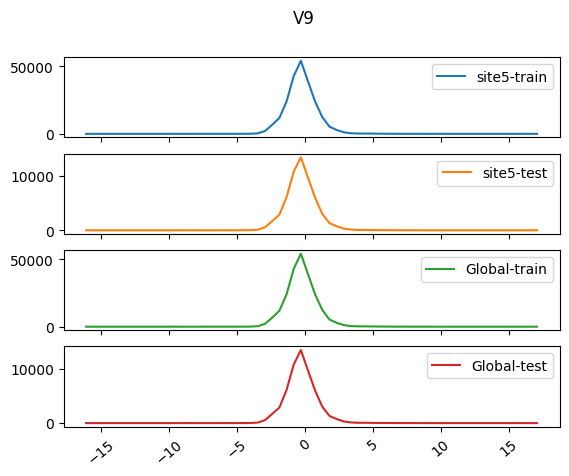

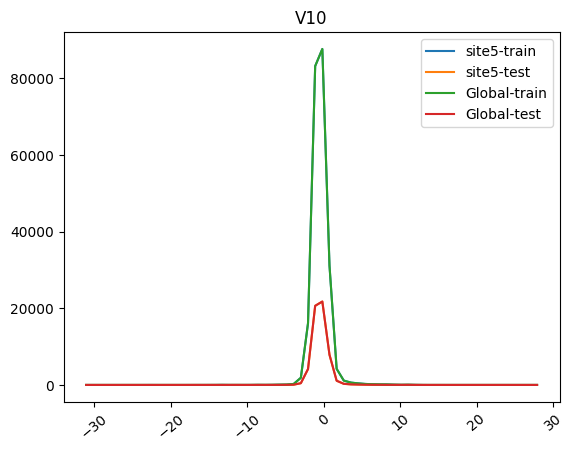

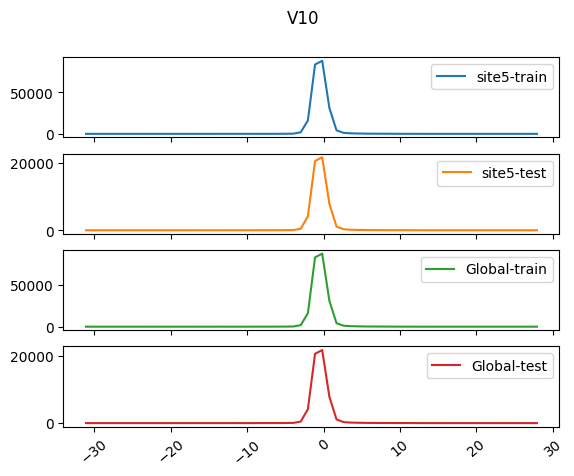

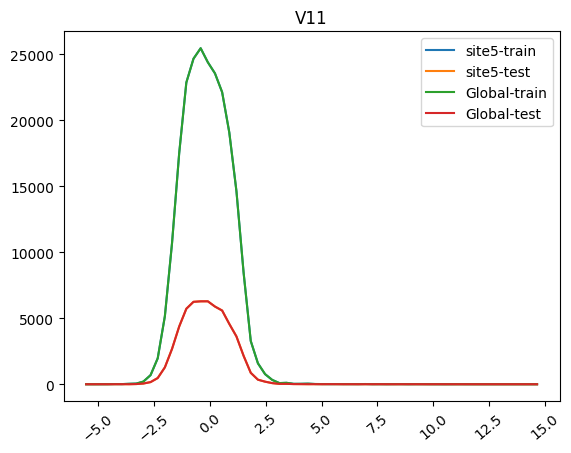

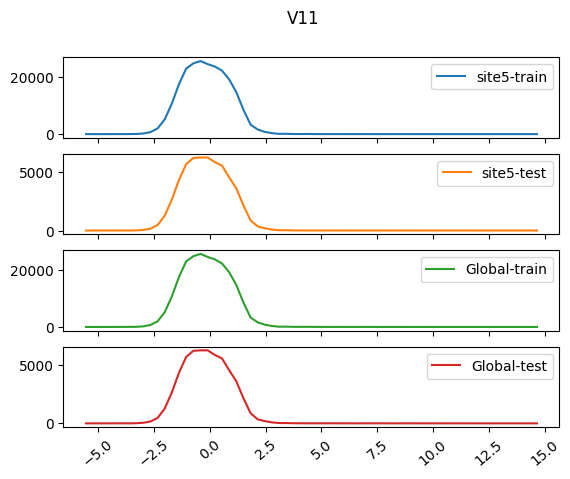

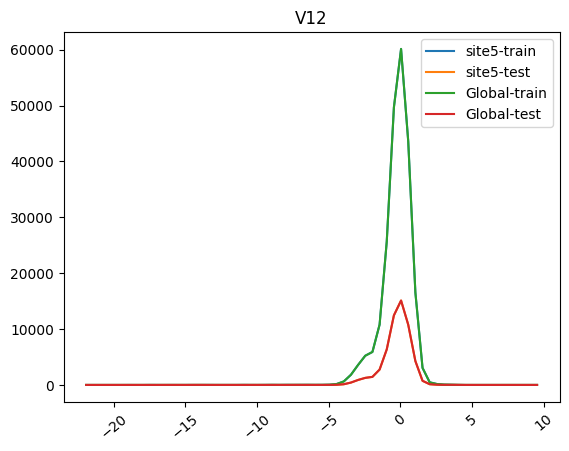

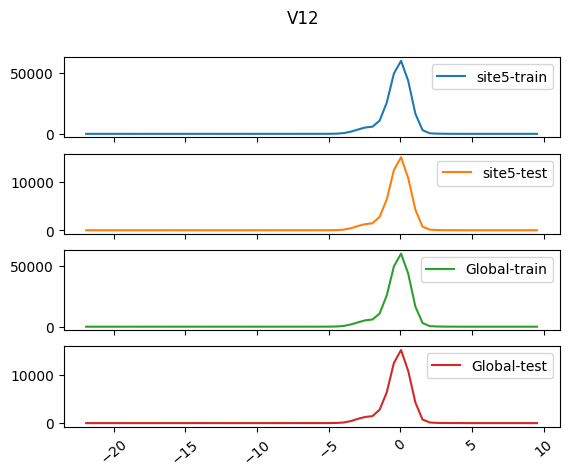

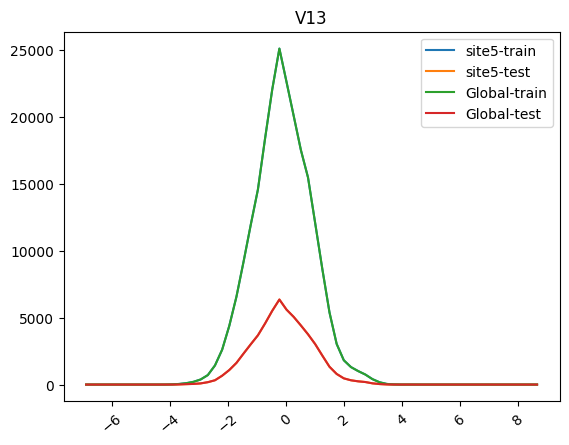

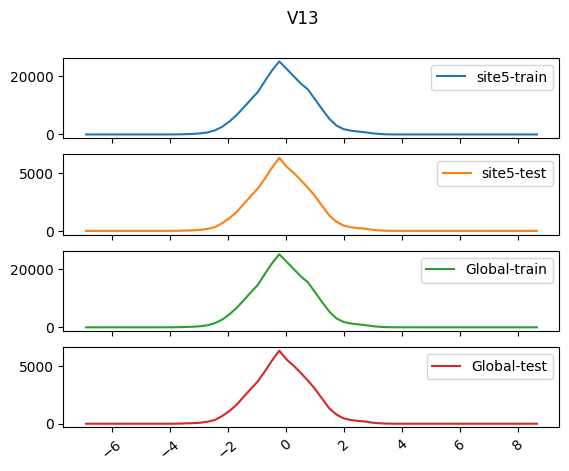

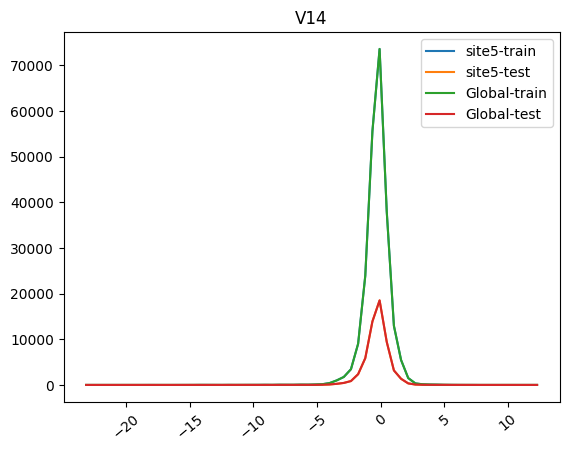

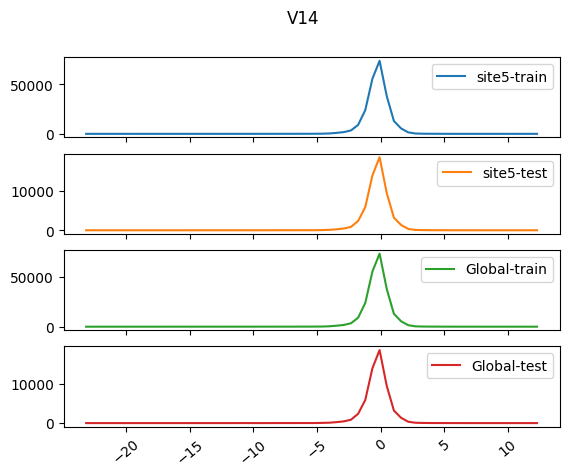

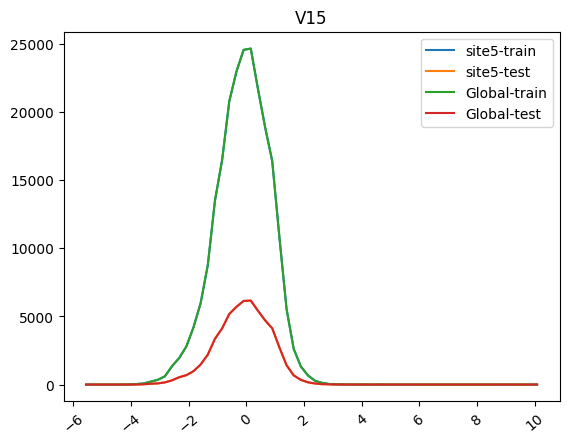

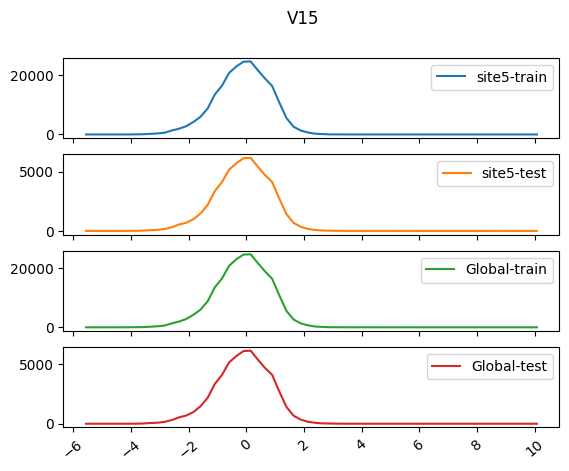

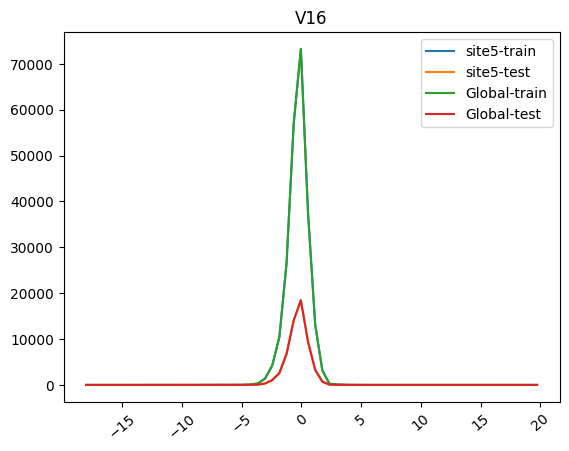

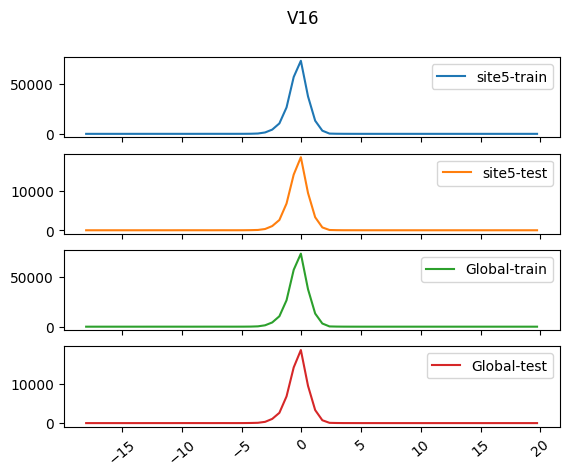

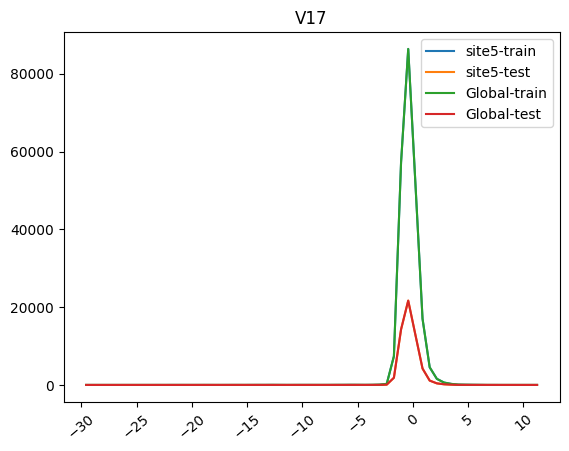

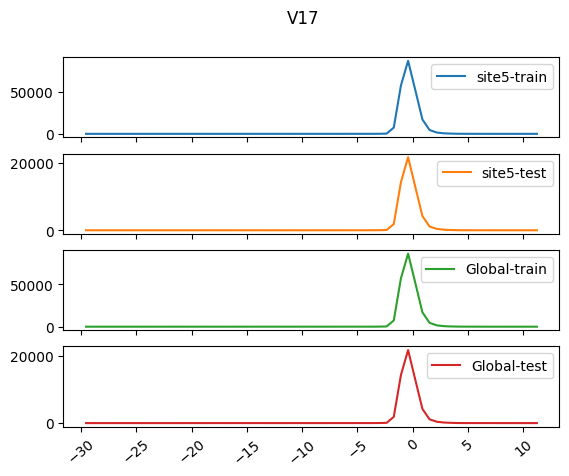

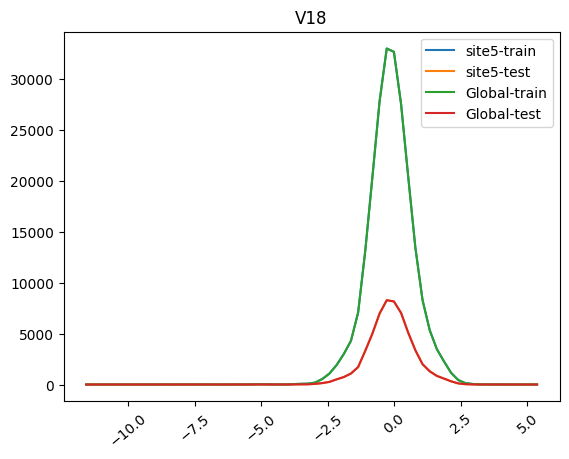

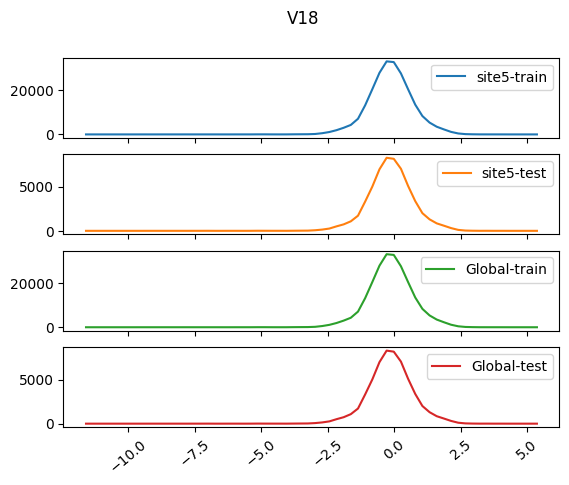

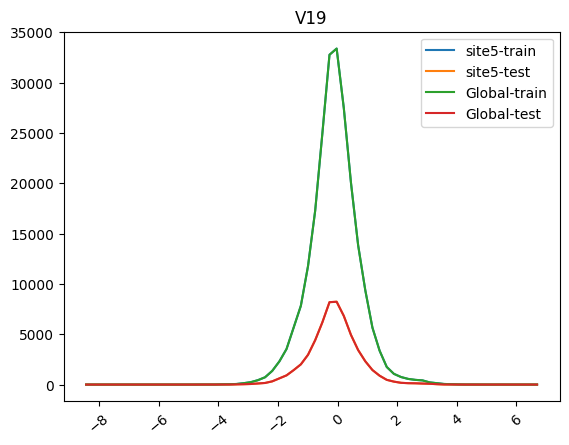

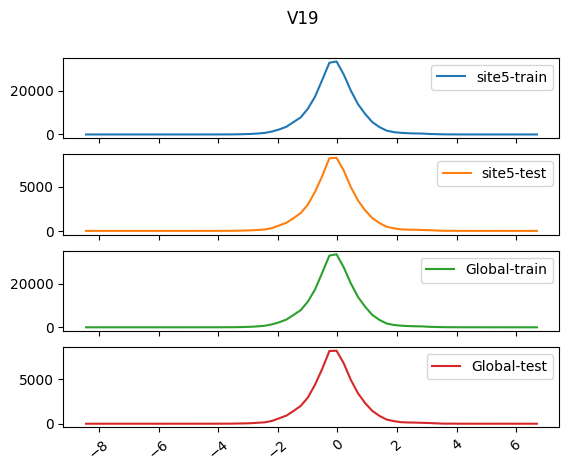

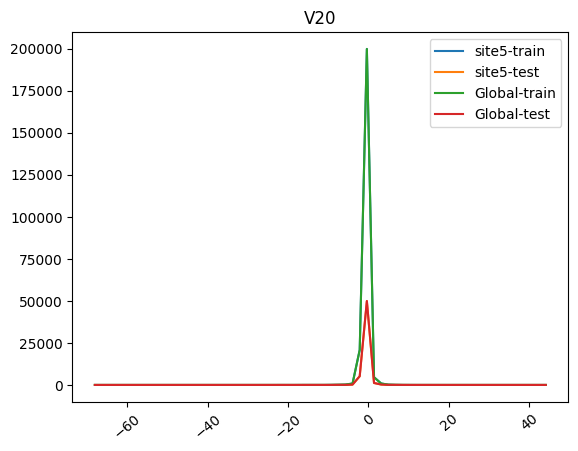

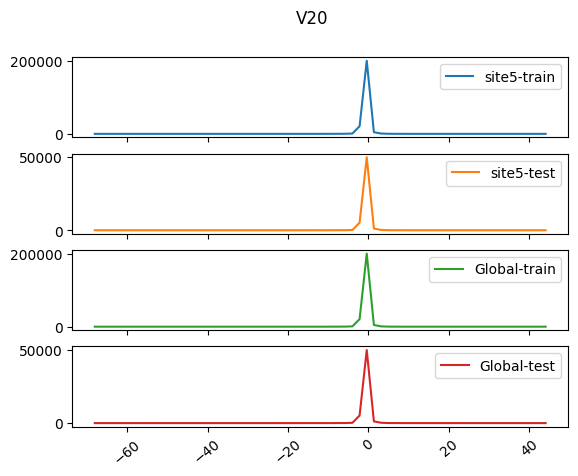

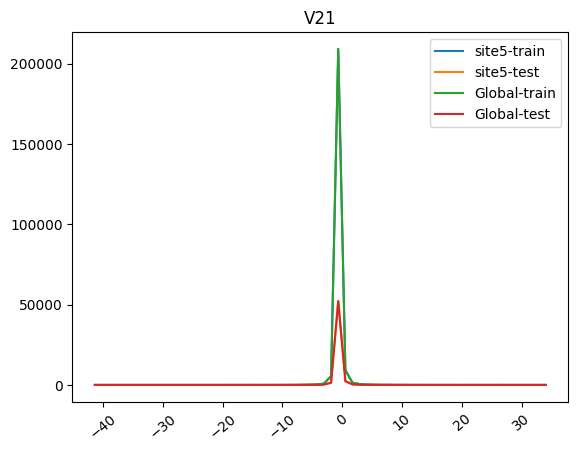

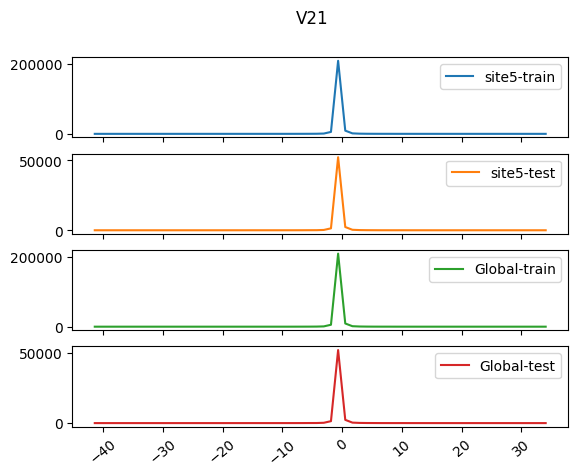

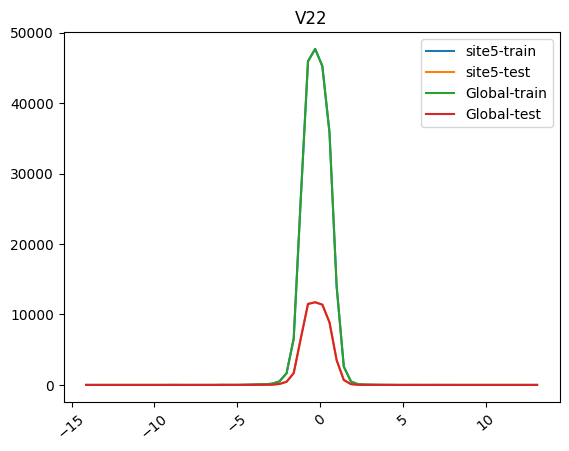

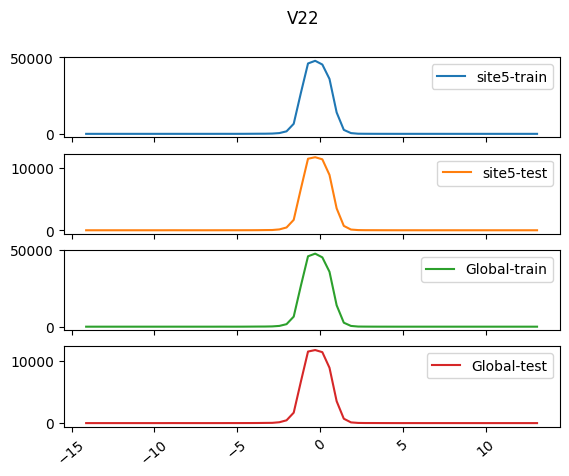

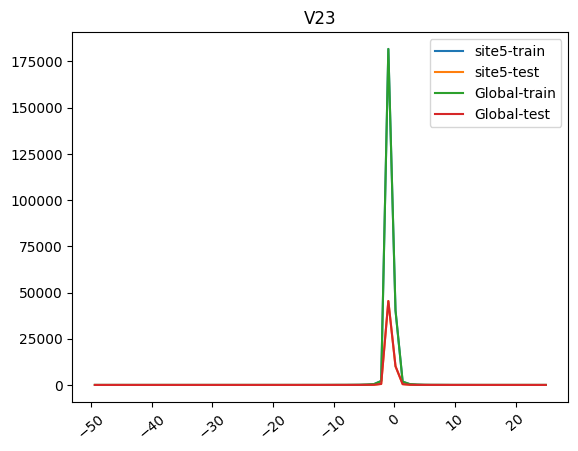

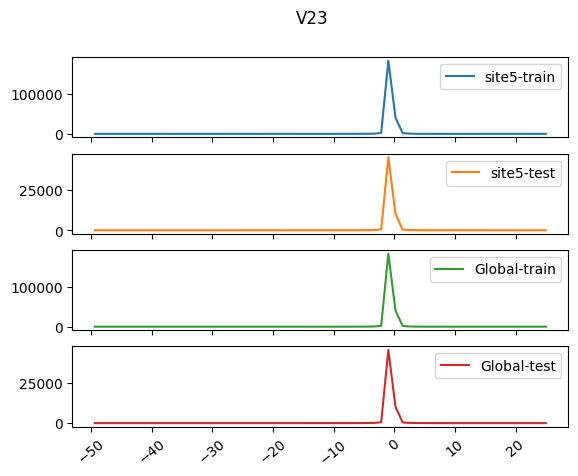

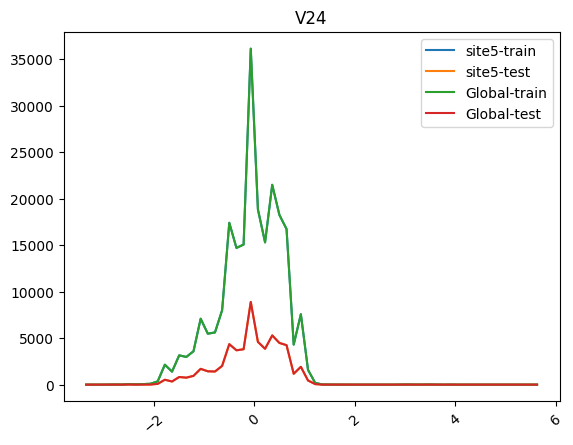

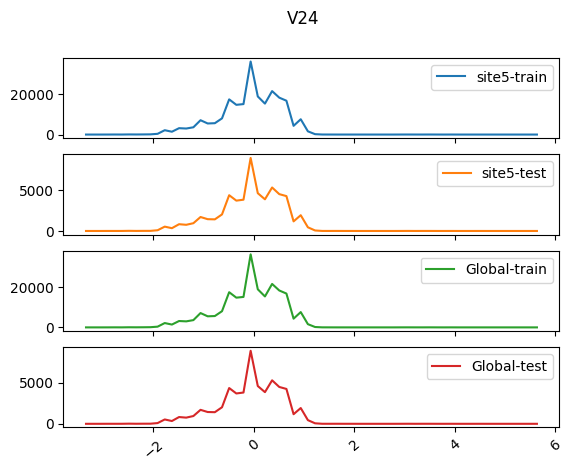

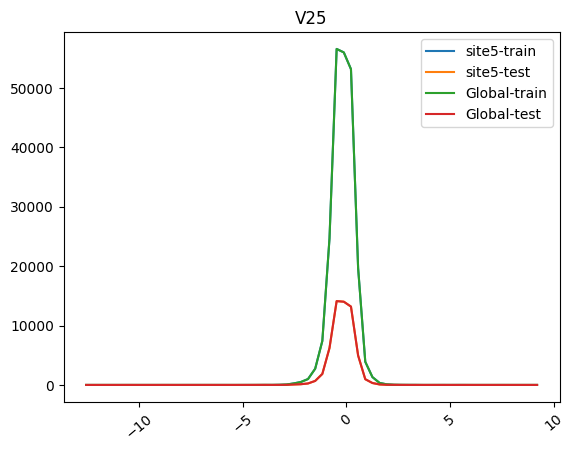

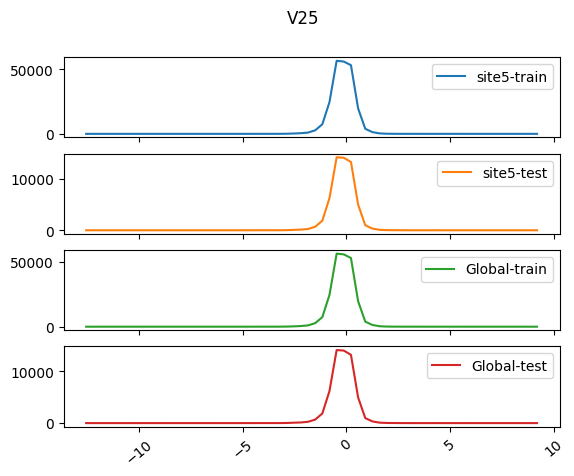

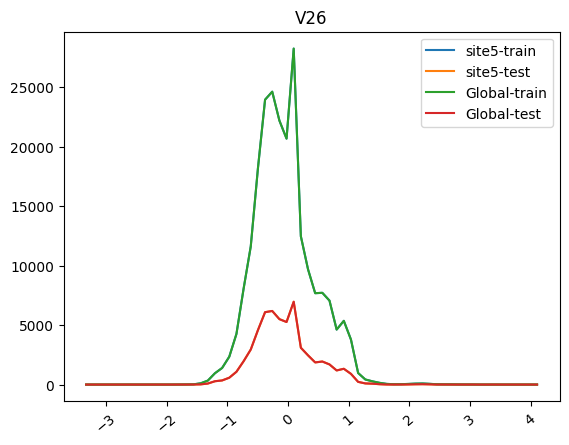

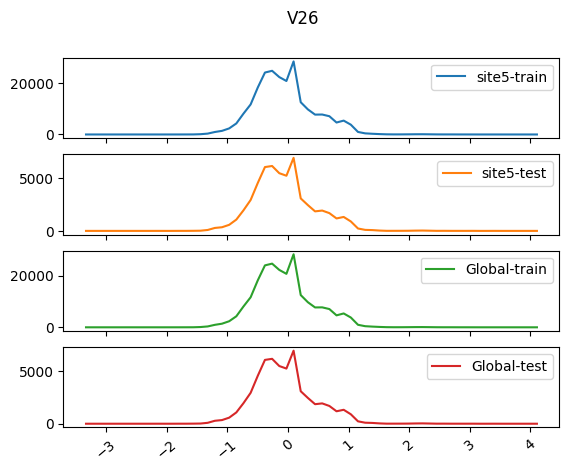

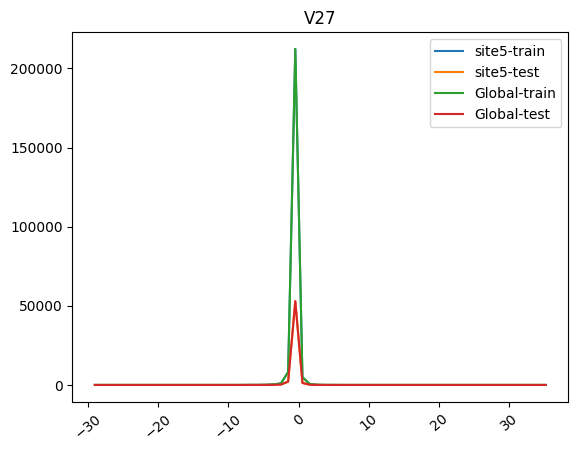

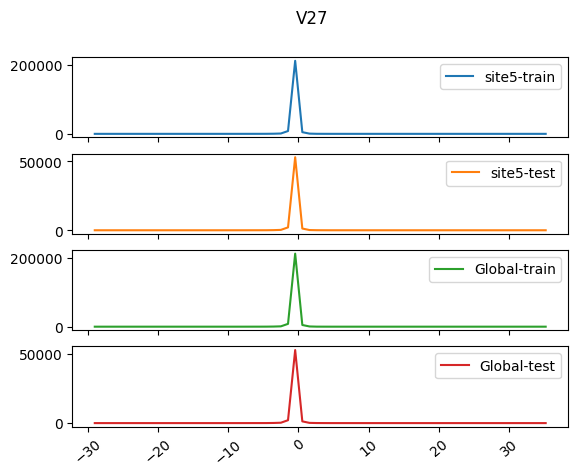

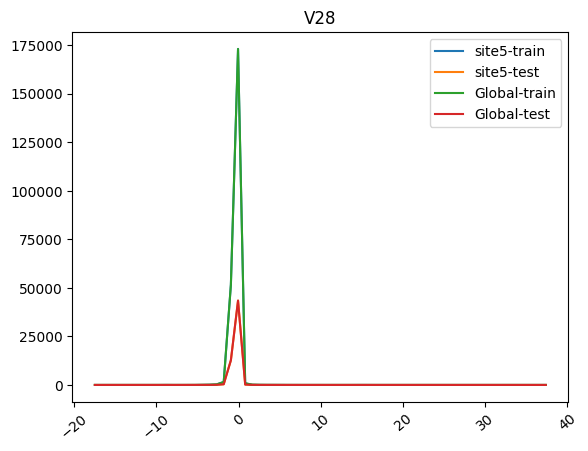

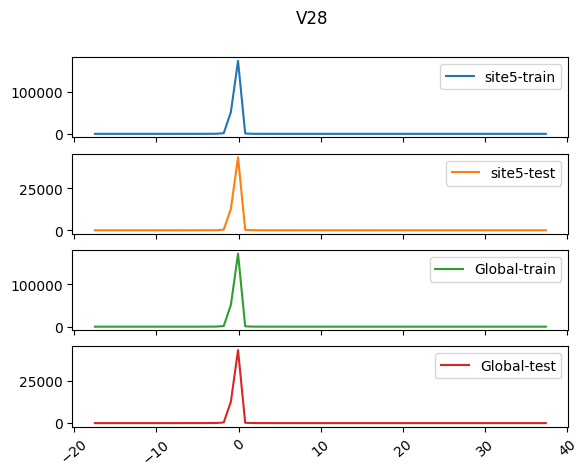

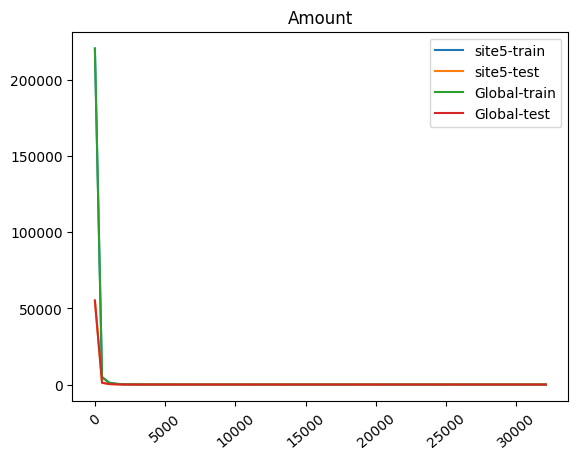

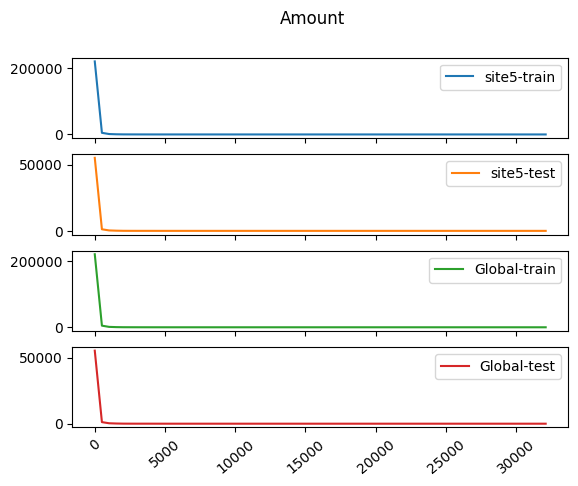

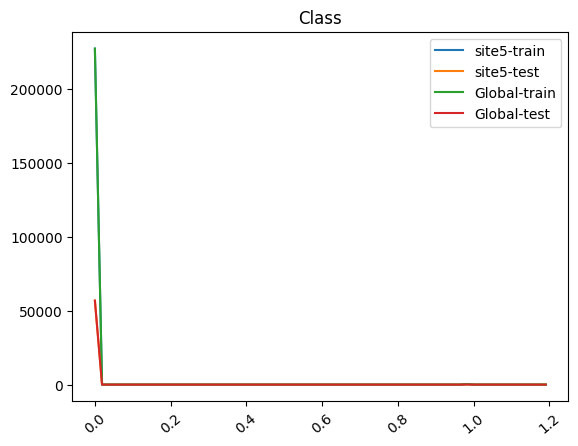

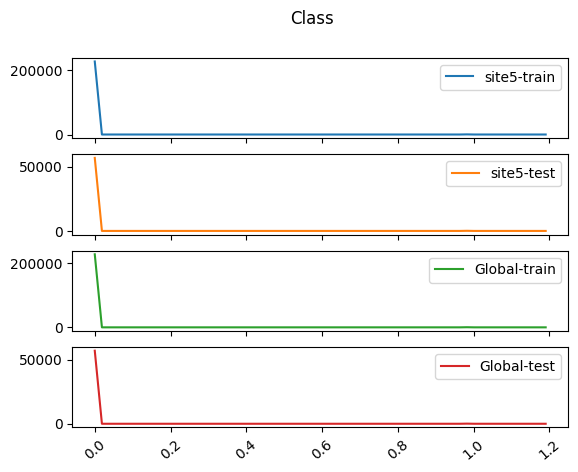

In [9]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100%  depth:100% !important; }</style>"))

vis.show_histograms(data = data)